# RF-22 · Predicción de Gastos con Machine Learning
**Módulo:** Predicción IA  
**Prioridad:** 🔴 Must Have  
**Relacionado con:** HU-09, CU-05, RF-23

---

Este notebook predice los gastos mensuales futuros por categoría usando modelos ML
entrenados con el historial de transacciones del usuario.

**Precondición:** Historial de al menos 3 meses de transacciones.

**Salidas:**
- Gasto estimado total para el próximo mes
- Predicción por categoría con rango de confianza (min–max)
- Gráfico predicción vs histórico
- Detección de tendencias
- Explicación del cálculo en lenguaje simple


## 📦 Dependencias

In [48]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, date
from collections import defaultdict
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("✅ Dependencias cargadas.")


✅ Dependencias cargadas.


## 📥 Parámetros de Entrada
Celda taggeada con `parameters` para inyección via papermill desde la app.

El historial necesita **mínimo 3 meses** de transacciones para entrenar el modelo.


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS DE ENTRADA — sustituir por datos reales desde la app
# ─────────────────────────────────────────────────────────────────────────────

transacciones = [
    # ── Agosto 2022 ───────────────────────────────────────────────────────────
    {"fecha": "2022-08-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2022-08-04", "monto": 85.00,  "categoria": "alimentacion"},
    {"fecha": "2022-08-09", "monto": 180.00, "categoria": "alimentacion"},
    {"fecha": "2022-08-12", "monto": 70.00,  "categoria": "transporte"},
    {"fecha": "2022-08-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2022-08-18", "monto": 140.00, "categoria": "ocio"},
    {"fecha": "2022-08-22", "monto": 45.00,  "categoria": "ropa"},
    {"fecha": "2022-08-25", "monto": 30.00,  "categoria": "salud"},
    {"fecha": "2022-08-28", "monto": 20.00,  "categoria": "otros"},
    # ── Septiembre 2022 ───────────────────────────────────────────────────────
    {"fecha": "2022-09-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2022-09-03", "monto": 92.00,  "categoria": "alimentacion"},
    {"fecha": "2022-09-08", "monto": 185.00, "categoria": "alimentacion"},
    {"fecha": "2022-09-11", "monto": 68.00,  "categoria": "transporte"},
    {"fecha": "2022-09-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2022-09-19", "monto": 110.00, "categoria": "ocio"},
    {"fecha": "2022-09-23", "monto": 60.00,  "categoria": "ropa"},
    {"fecha": "2022-09-26", "monto": 35.00,  "categoria": "salud"},
    {"fecha": "2022-09-29", "monto": 18.00,  "categoria": "otros"},
    # ── Octubre 2022 ──────────────────────────────────────────────────────────
    {"fecha": "2022-10-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2022-10-04", "monto": 98.00,  "categoria": "alimentacion"},
    {"fecha": "2022-10-08", "monto": 190.00, "categoria": "alimentacion"},
    {"fecha": "2022-10-12", "monto": 72.00,  "categoria": "transporte"},
    {"fecha": "2022-10-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2022-10-19", "monto": 100.00, "categoria": "ocio"},
    {"fecha": "2022-10-22", "monto": 55.00,  "categoria": "ropa"},
    {"fecha": "2022-10-26", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2022-10-30", "monto": 22.00,  "categoria": "otros"},
    # ── Noviembre 2022 ────────────────────────────────────────────────────────
    {"fecha": "2022-11-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2022-11-04", "monto": 95.00,  "categoria": "alimentacion"},
    {"fecha": "2022-11-08", "monto": 195.00, "categoria": "alimentacion"},
    {"fecha": "2022-11-11", "monto": 74.00,  "categoria": "transporte"},
    {"fecha": "2022-11-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2022-11-18", "monto": 115.00, "categoria": "ocio"},
    {"fecha": "2022-11-22", "monto": 50.00,  "categoria": "ropa"},
    {"fecha": "2022-11-25", "monto": 38.00,  "categoria": "salud"},
    {"fecha": "2022-11-28", "monto": 25.00,  "categoria": "otros"},
    # ── Diciembre 2022 ────────────────────────────────────────────────────────
    {"fecha": "2022-12-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2022-12-05", "monto": 120.00, "categoria": "alimentacion"},
    {"fecha": "2022-12-09", "monto": 240.00, "categoria": "alimentacion"},
    {"fecha": "2022-12-13", "monto": 80.00,  "categoria": "transporte"},
    {"fecha": "2022-12-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2022-12-19", "monto": 280.00, "categoria": "ocio"},
    {"fecha": "2022-12-22", "monto": 190.00, "categoria": "ropa"},
    {"fecha": "2022-12-26", "monto": 65.00,  "categoria": "salud"},
    {"fecha": "2022-12-29", "monto": 45.00,  "categoria": "otros"},
    # ── Enero 2023 ────────────────────────────────────────────────────────────
    {"fecha": "2023-01-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-01-05", "monto": 88.00,  "categoria": "alimentacion"},
    {"fecha": "2023-01-09", "monto": 178.00, "categoria": "alimentacion"},
    {"fecha": "2023-01-12", "monto": 70.00,  "categoria": "transporte"},
    {"fecha": "2023-01-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2023-01-18", "monto": 90.00,  "categoria": "ocio"},
    {"fecha": "2023-01-22", "monto": 35.00,  "categoria": "ropa"},
    {"fecha": "2023-01-25", "monto": 42.00,  "categoria": "salud"},
    {"fecha": "2023-01-28", "monto": 18.00,  "categoria": "otros"},
    # ── Febrero 2023 ──────────────────────────────────────────────────────────
    {"fecha": "2023-02-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-02-04", "monto": 91.00,  "categoria": "alimentacion"},
    {"fecha": "2023-02-08", "monto": 182.00, "categoria": "alimentacion"},
    {"fecha": "2023-02-12", "monto": 69.00,  "categoria": "transporte"},
    {"fecha": "2023-02-14", "monto": 75.00,  "categoria": "ocio"},
    {"fecha": "2023-02-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2023-02-20", "monto": 44.00,  "categoria": "salud"},
    {"fecha": "2023-02-23", "monto": 40.00,  "categoria": "ropa"},
    {"fecha": "2023-02-26", "monto": 20.00,  "categoria": "otros"},
    # ── Marzo 2023 ────────────────────────────────────────────────────────────
    {"fecha": "2023-03-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-03-04", "monto": 94.00,  "categoria": "alimentacion"},
    {"fecha": "2023-03-08", "monto": 188.00, "categoria": "alimentacion"},
    {"fecha": "2023-03-11", "monto": 73.00,  "categoria": "transporte"},
    {"fecha": "2023-03-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2023-03-18", "monto": 105.00, "categoria": "ocio"},
    {"fecha": "2023-03-22", "monto": 48.00,  "categoria": "ropa"},
    {"fecha": "2023-03-26", "monto": 36.00,  "categoria": "salud"},
    {"fecha": "2023-03-29", "monto": 22.00,  "categoria": "otros"},
    # ── Abril 2023 ────────────────────────────────────────────────────────────
    {"fecha": "2023-04-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-04-04", "monto": 96.00,  "categoria": "alimentacion"},
    {"fecha": "2023-04-08", "monto": 192.00, "categoria": "alimentacion"},
    {"fecha": "2023-04-12", "monto": 76.00,  "categoria": "transporte"},
    {"fecha": "2023-04-15", "monto": 55.00,  "categoria": "suscripciones"},
    {"fecha": "2023-04-18", "monto": 130.00, "categoria": "ocio"},
    {"fecha": "2023-04-22", "monto": 52.00,  "categoria": "ropa"},
    {"fecha": "2023-04-26", "monto": 33.00,  "categoria": "salud"},
    {"fecha": "2023-04-29", "monto": 24.00,  "categoria": "otros"},
    # ── Mayo 2023 ─────────────────────────────────────────────────────────────
    {"fecha": "2023-05-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-05-04", "monto": 100.00, "categoria": "alimentacion"},
    {"fecha": "2023-05-08", "monto": 198.00, "categoria": "alimentacion"},
    {"fecha": "2023-05-12", "monto": 74.00,  "categoria": "transporte"},
    {"fecha": "2023-05-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-05-18", "monto": 145.00, "categoria": "ocio"},
    {"fecha": "2023-05-22", "monto": 55.00,  "categoria": "ropa"},
    {"fecha": "2023-05-26", "monto": 38.00,  "categoria": "salud"},
    {"fecha": "2023-05-29", "monto": 26.00,  "categoria": "otros"},
    # ── Junio 2023 ────────────────────────────────────────────────────────────
    {"fecha": "2023-06-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-06-04", "monto": 102.00, "categoria": "alimentacion"},
    {"fecha": "2023-06-08", "monto": 205.00, "categoria": "alimentacion"},
    {"fecha": "2023-06-12", "monto": 78.00,  "categoria": "transporte"},
    {"fecha": "2023-06-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-06-18", "monto": 160.00, "categoria": "ocio"},
    {"fecha": "2023-06-22", "monto": 60.00,  "categoria": "ropa"},
    {"fecha": "2023-06-26", "monto": 35.00,  "categoria": "salud"},
    {"fecha": "2023-06-29", "monto": 28.00,  "categoria": "otros"},
    # ── Julio 2023 ────────────────────────────────────────────────────────────
    {"fecha": "2023-07-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-07-04", "monto": 105.00, "categoria": "alimentacion"},
    {"fecha": "2023-07-08", "monto": 210.00, "categoria": "alimentacion"},
    {"fecha": "2023-07-12", "monto": 80.00,  "categoria": "transporte"},
    {"fecha": "2023-07-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-07-18", "monto": 175.00, "categoria": "ocio"},
    {"fecha": "2023-07-22", "monto": 65.00,  "categoria": "ropa"},
    {"fecha": "2023-07-26", "monto": 32.00,  "categoria": "salud"},
    {"fecha": "2023-07-29", "monto": 30.00,  "categoria": "otros"},
    # ── Agosto 2023 ───────────────────────────────────────────────────────────
    {"fecha": "2023-08-01", "monto": 720.00, "categoria": "vivienda"},
    {"fecha": "2023-08-04", "monto": 98.00,  "categoria": "alimentacion"},
    {"fecha": "2023-08-08", "monto": 200.00, "categoria": "alimentacion"},
    {"fecha": "2023-08-12", "monto": 76.00,  "categoria": "transporte"},
    {"fecha": "2023-08-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-08-18", "monto": 180.00, "categoria": "ocio"},
    {"fecha": "2023-08-22", "monto": 58.00,  "categoria": "ropa"},
    {"fecha": "2023-08-26", "monto": 34.00,  "categoria": "salud"},
    {"fecha": "2023-08-29", "monto": 27.00,  "categoria": "otros"},
    # ── Septiembre 2023 ───────────────────────────────────────────────────────
    {"fecha": "2023-09-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2023-09-04", "monto": 100.00, "categoria": "alimentacion"},
    {"fecha": "2023-09-08", "monto": 198.00, "categoria": "alimentacion"},
    {"fecha": "2023-09-12", "monto": 74.00,  "categoria": "transporte"},
    {"fecha": "2023-09-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-09-19", "monto": 120.00, "categoria": "ocio"},
    {"fecha": "2023-09-22", "monto": 52.00,  "categoria": "ropa"},
    {"fecha": "2023-09-26", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2023-09-29", "monto": 22.00,  "categoria": "otros"},
    # ── Octubre 2023 ──────────────────────────────────────────────────────────
    {"fecha": "2023-10-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2023-10-04", "monto": 103.00, "categoria": "alimentacion"},
    {"fecha": "2023-10-08", "monto": 202.00, "categoria": "alimentacion"},
    {"fecha": "2023-10-12", "monto": 77.00,  "categoria": "transporte"},
    {"fecha": "2023-10-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-10-19", "monto": 108.00, "categoria": "ocio"},
    {"fecha": "2023-10-22", "monto": 54.00,  "categoria": "ropa"},
    {"fecha": "2023-10-26", "monto": 42.00,  "categoria": "salud"},
    {"fecha": "2023-10-29", "monto": 24.00,  "categoria": "otros"},
    # ── Noviembre 2023 ────────────────────────────────────────────────────────
    {"fecha": "2023-11-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2023-11-04", "monto": 106.00, "categoria": "alimentacion"},
    {"fecha": "2023-11-08", "monto": 208.00, "categoria": "alimentacion"},
    {"fecha": "2023-11-12", "monto": 79.00,  "categoria": "transporte"},
    {"fecha": "2023-11-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-11-18", "monto": 125.00, "categoria": "ocio"},
    {"fecha": "2023-11-22", "monto": 56.00,  "categoria": "ropa"},
    {"fecha": "2023-11-26", "monto": 44.00,  "categoria": "salud"},
    {"fecha": "2023-11-29", "monto": 26.00,  "categoria": "otros"},
    # ── Diciembre 2023 ────────────────────────────────────────────────────────
    {"fecha": "2023-12-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2023-12-05", "monto": 125.00, "categoria": "alimentacion"},
    {"fecha": "2023-12-09", "monto": 255.00, "categoria": "alimentacion"},
    {"fecha": "2023-12-13", "monto": 85.00,  "categoria": "transporte"},
    {"fecha": "2023-12-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2023-12-19", "monto": 295.00, "categoria": "ocio"},
    {"fecha": "2023-12-22", "monto": 200.00, "categoria": "ropa"},
    {"fecha": "2023-12-26", "monto": 68.00,  "categoria": "salud"},
    {"fecha": "2023-12-29", "monto": 48.00,  "categoria": "otros"},
    # ── Enero 2024 ────────────────────────────────────────────────────────────
    {"fecha": "2024-01-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-01-05", "monto": 92.00,  "categoria": "alimentacion"},
    {"fecha": "2024-01-09", "monto": 185.00, "categoria": "alimentacion"},
    {"fecha": "2024-01-12", "monto": 72.00,  "categoria": "transporte"},
    {"fecha": "2024-01-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-01-18", "monto": 95.00,  "categoria": "ocio"},
    {"fecha": "2024-01-22", "monto": 38.00,  "categoria": "ropa"},
    {"fecha": "2024-01-26", "monto": 45.00,  "categoria": "salud"},
    {"fecha": "2024-01-29", "monto": 20.00,  "categoria": "otros"},
    # ── Febrero 2024 ──────────────────────────────────────────────────────────
    {"fecha": "2024-02-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-02-04", "monto": 94.00,  "categoria": "alimentacion"},
    {"fecha": "2024-02-08", "monto": 188.00, "categoria": "alimentacion"},
    {"fecha": "2024-02-12", "monto": 74.00,  "categoria": "transporte"},
    {"fecha": "2024-02-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-02-18", "monto": 110.00, "categoria": "ocio"},
    {"fecha": "2024-02-22", "monto": 45.00,  "categoria": "ropa"},
    {"fecha": "2024-02-26", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2024-02-28", "monto": 22.00,  "categoria": "otros"},
    # ── Marzo 2024 ────────────────────────────────────────────────────────────
    {"fecha": "2024-03-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-03-04", "monto": 98.00,  "categoria": "alimentacion"},
    {"fecha": "2024-03-08", "monto": 195.00, "categoria": "alimentacion"},
    {"fecha": "2024-03-11", "monto": 76.00,  "categoria": "transporte"},
    {"fecha": "2024-03-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-03-18", "monto": 120.00, "categoria": "ocio"},
    {"fecha": "2024-03-22", "monto": 50.00,  "categoria": "ropa"},
    {"fecha": "2024-03-26", "monto": 35.00,  "categoria": "salud"},
    {"fecha": "2024-03-29", "monto": 25.00,  "categoria": "otros"},
    # ── Abril 2024 ────────────────────────────────────────────────────────────
    {"fecha": "2024-04-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-04-04", "monto": 102.00, "categoria": "alimentacion"},
    {"fecha": "2024-04-08", "monto": 200.00, "categoria": "alimentacion"},
    {"fecha": "2024-04-12", "monto": 78.00,  "categoria": "transporte"},
    {"fecha": "2024-04-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-04-18", "monto": 140.00, "categoria": "ocio"},
    {"fecha": "2024-04-22", "monto": 55.00,  "categoria": "ropa"},
    {"fecha": "2024-04-26", "monto": 42.00,  "categoria": "salud"},
    {"fecha": "2024-04-29", "monto": 28.00,  "categoria": "otros"},
    # ── Mayo 2024 ─────────────────────────────────────────────────────────────
    {"fecha": "2024-05-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-05-04", "monto": 105.00, "categoria": "alimentacion"},
    {"fecha": "2024-05-08", "monto": 210.00, "categoria": "alimentacion"},
    {"fecha": "2024-05-12", "monto": 80.00,  "categoria": "transporte"},
    {"fecha": "2024-05-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-05-18", "monto": 135.00, "categoria": "ocio"},
    {"fecha": "2024-05-22", "monto": 60.00,  "categoria": "ropa"},
    {"fecha": "2024-05-26", "monto": 38.00,  "categoria": "salud"},
    {"fecha": "2024-05-29", "monto": 30.00,  "categoria": "otros"},
    # ── Junio 2024 ────────────────────────────────────────────────────────────
    {"fecha": "2024-06-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-06-04", "monto": 98.00,  "categoria": "alimentacion"},
    {"fecha": "2024-06-08", "monto": 192.00, "categoria": "alimentacion"},
    {"fecha": "2024-06-12", "monto": 75.00,  "categoria": "transporte"},
    {"fecha": "2024-06-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-06-18", "monto": 150.00, "categoria": "ocio"},
    {"fecha": "2024-06-22", "monto": 52.00,  "categoria": "ropa"},
    {"fecha": "2024-06-26", "monto": 45.00,  "categoria": "salud"},
    {"fecha": "2024-06-29", "monto": 26.00,  "categoria": "otros"},
    # ── Julio 2024 ────────────────────────────────────────────────────────────
    {"fecha": "2024-07-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-07-04", "monto": 110.00, "categoria": "alimentacion"},
    {"fecha": "2024-07-08", "monto": 215.00, "categoria": "alimentacion"},
    {"fecha": "2024-07-12", "monto": 82.00,  "categoria": "transporte"},
    {"fecha": "2024-07-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-07-18", "monto": 180.00, "categoria": "ocio"},
    {"fecha": "2024-07-22", "monto": 65.00,  "categoria": "ropa"},
    {"fecha": "2024-07-26", "monto": 32.00,  "categoria": "salud"},
    {"fecha": "2024-07-29", "monto": 35.00,  "categoria": "otros"},
    # ── Agosto 2024 ───────────────────────────────────────────────────────────
    {"fecha": "2024-08-01", "monto": 735.00, "categoria": "vivienda"},
    {"fecha": "2024-08-04", "monto": 105.00, "categoria": "alimentacion"},
    {"fecha": "2024-08-08", "monto": 205.00, "categoria": "alimentacion"},
    {"fecha": "2024-08-12", "monto": 79.00,  "categoria": "transporte"},
    {"fecha": "2024-08-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-08-18", "monto": 190.00, "categoria": "ocio"},
    {"fecha": "2024-08-22", "monto": 58.00,  "categoria": "ropa"},
    {"fecha": "2024-08-26", "monto": 36.00,  "categoria": "salud"},
    {"fecha": "2024-08-29", "monto": 28.00,  "categoria": "otros"},
    # ── Septiembre 2024 ───────────────────────────────────────────────────────
    {"fecha": "2024-09-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-09-03", "monto": 90.00,  "categoria": "alimentacion"},
    {"fecha": "2024-09-07", "monto": 200.00, "categoria": "alimentacion"},
    {"fecha": "2024-09-10", "monto": 75.00,  "categoria": "transporte"},
    {"fecha": "2024-09-14", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2024-09-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-09-20", "monto": 120.00, "categoria": "ocio"},
    {"fecha": "2024-09-24", "monto": 50.00,  "categoria": "ropa"},
    {"fecha": "2024-09-28", "monto": 25.00,  "categoria": "otros"},
    # ── Octubre 2024 ──────────────────────────────────────────────────────────
    {"fecha": "2024-10-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-10-04", "monto": 105.00, "categoria": "alimentacion"},
    {"fecha": "2024-10-08", "monto": 195.00, "categoria": "alimentacion"},
    {"fecha": "2024-10-11", "monto": 80.00,  "categoria": "transporte"},
    {"fecha": "2024-10-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-10-17", "monto": 95.00,  "categoria": "ocio"},
    {"fecha": "2024-10-21", "monto": 65.00,  "categoria": "ropa"},
    {"fecha": "2024-10-25", "monto": 55.00,  "categoria": "salud"},
    {"fecha": "2024-10-29", "monto": 30.00,  "categoria": "otros"},
    # ── Noviembre 2024 ────────────────────────────────────────────────────────
    {"fecha": "2024-11-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-11-03", "monto": 95.00,  "categoria": "alimentacion"},
    {"fecha": "2024-11-07", "monto": 210.00, "categoria": "alimentacion"},
    {"fecha": "2024-11-10", "monto": 78.00,  "categoria": "transporte"},
    {"fecha": "2024-11-14", "monto": 45.00,  "categoria": "salud"},
    {"fecha": "2024-11-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-11-18", "monto": 130.00, "categoria": "ocio"},
    {"fecha": "2024-11-22", "monto": 55.00,  "categoria": "ropa"},
    {"fecha": "2024-11-28", "monto": 30.00,  "categoria": "otros"},
    # ── Diciembre 2024 ────────────────────────────────────────────────────────
    {"fecha": "2024-12-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-12-04", "monto": 115.00, "categoria": "alimentacion"},
    {"fecha": "2024-12-09", "monto": 230.00, "categoria": "alimentacion"},
    {"fecha": "2024-12-12", "monto": 88.00,  "categoria": "transporte"},
    {"fecha": "2024-12-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-12-19", "monto": 290.00, "categoria": "ocio"},
    {"fecha": "2024-12-22", "monto": 180.00, "categoria": "ropa"},
    {"fecha": "2024-12-26", "monto": 70.00,  "categoria": "salud"},
    {"fecha": "2024-12-29", "monto": 50.00,  "categoria": "otros"},
    # ── Enero 2025 ────────────────────────────────────────────────────────────
    {"fecha": "2025-01-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2025-01-05", "monto": 100.00, "categoria": "alimentacion"},
    {"fecha": "2025-01-09", "monto": 195.00, "categoria": "alimentacion"},
    {"fecha": "2025-01-11", "monto": 82.00,  "categoria": "transporte"},
    {"fecha": "2025-01-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2025-01-18", "monto": 110.00, "categoria": "ocio"},
    {"fecha": "2025-01-21", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2025-01-25", "monto": 35.00,  "categoria": "ropa"},
    {"fecha": "2025-01-28", "monto": 25.00,  "categoria": "otros"},
    # ── Febrero 2025 ──────────────────────────────────────────────────────────
    {"fecha": "2025-02-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2025-02-04", "monto": 108.00, "categoria": "alimentacion"},
    {"fecha": "2025-02-08", "monto": 205.00, "categoria": "alimentacion"},
    {"fecha": "2025-02-12", "monto": 75.00,  "categoria": "transporte"},
    {"fecha": "2025-02-14", "monto": 85.00,  "categoria": "ocio"},
    {"fecha": "2025-02-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2025-02-20", "monto": 55.00,  "categoria": "salud"},
    {"fecha": "2025-02-22", "monto": 30.00,  "categoria": "ropa"},
    {"fecha": "2025-02-26", "monto": 20.00,  "categoria": "otros"},
]

fecha_prediccion = "2025-03"
PRECISION_MINIMA = 0.70

## ⚙️ 1. Preparación de Datos

In [51]:
from collections import defaultdict

# ── LOGICA DE PROCESAMIENTO ──────────────────────────────────────────────────

def agrupar_por_mes_categoria(transacciones: list) -> dict:
    """
    Agrupa gastos por mes y categoría.
    Devuelve: {"YYYY-MM": {"categoria": total, ...}, ...} ordenado cronológicamente.
    """
    meses = defaultdict(lambda: defaultdict(float))
    for t in transacciones:
        clave = t["fecha"][:7]
        meses[clave][t["categoria"]] += t["monto"]
    return dict(sorted(meses.items()))

def construir_series_temporales(meses_data: dict) -> dict:
    """
    Construye una serie temporal por categoría con índice numérico de mes.
    Rellena con 0 los meses sin gasto en esa categoría.
    """
    meses_list  = sorted(meses_data.keys())
    categorias  = sorted({cat for m in meses_data.values() for cat in m})
    series = {}
    for cat in categorias:
        series[cat] = [meses_data[m].get(cat, 0.0) for m in meses_list]
    # Total mensual
    series["__total__"] = [sum(meses_data[m].values()) for m in meses_list]
    return series, meses_list, categorias

# ── EJECUCIÓN Y RENDERIZADO ──────────────────────────────────────────────────

meses_data = agrupar_por_mes_categoria(transacciones)
series, meses_list, categorias = construir_series_temporales(meses_data)

# Configuración de anchos para la tabla
ancho_mes = 10
ancho_cat = 13
cabecera_cats = categorias + ["TOTAL"]
linea_separadora = "─" * (ancho_mes + 3 + (ancho_cat * len(cabecera_cats)))

print(f"\nREPORTE HISTÓRICO DE GASTOS ({len(meses_list)} meses)")
print(linea_separadora)

# Imprimir Cabecera: Mes | Categoria1 | Categoria2 ... | TOTAL
print(f"{'Mes':<{ancho_mes}} |", end="")
for cat in cabecera_cats:
    print(f"{cat.upper():>{ancho_cat}}", end="")
print()
print(linea_separadora)

# Imprimir Filas: Cada mes es una línea
for i, mes in enumerate(meses_list):
    print(f"{mes:<{ancho_mes}} |", end="")
    
    # Montos por categoría
    for cat in categorias:
        monto = series[cat][i]
        print(f"{monto:>{ancho_cat}.2f}", end="")
    
    # Total del mes (en negrita visual o resaltado por posición)
    total_mes = series["__total__"][i]
    print(f"{total_mes:>{ancho_cat}.2f}")

print(linea_separadora)


REPORTE HISTÓRICO DE GASTOS (31 meses)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Mes        | ALIMENTACION         OCIO        OTROS         ROPA        SALUDSUSCRIPCIONES   TRANSPORTE     VIVIENDA        TOTAL
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
2022-08    |       265.00       140.00        20.00        45.00        30.00        55.00        70.00       720.00      1345.00
2022-09    |       277.00       110.00        18.00        60.00        35.00        55.00        68.00       720.00      1343.00
2022-10    |       288.00       100.00        22.00        55.00        40.00        55.00        72.00       720.00      1352.00
2022-11    |       290.00       115.00        25.00        50.00        38.00        55.00        74.00       720.00      1367.00
2022-12    |       360.00       280.00        45

## 🛠️ 2. Feature Engineering
Construimos features temporales para que el modelo pueda aprender patrones de estacionalidad y tendencia.


In [52]:
def construir_features(serie: list, ventana: int = 2) -> tuple:
    """
    Para una serie temporal [v0, v1, v2, ...] construye:
      X: matriz de features (lags, media móvil, índice temporal, mes del año)
      y: vector target (valor siguiente)
    """
    X, y = [], []
    for i in range(ventana, len(serie)):
        lags      = serie[i - ventana: i]                       # valores anteriores
        media_mov = np.mean(lags)                               # media de la ventana
        tendencia = lags[-1] - lags[0] if ventana > 1 else 0.0 # pendiente simple
        idx_mes   = i                                           # índice ordinal
        # Mes del calendario (para estacionalidad) — extraído de meses_list
        mes_cal   = int(meses_list[i].split("-")[1])

        fila = list(lags) + [media_mov, tendencia, idx_mes, mes_cal]
        X.append(fila)
        y.append(serie[i])
    return np.array(X, dtype=float), np.array(y, dtype=float)


# Nombres de features para explicabilidad
VENTANA = 2
feat_names_base = (
    [f"lag_{i+1}" for i in range(VENTANA)] +
    ["media_movil", "tendencia", "idx_mes", "mes_calendario"]
)

# Verificar que hay suficientes datos
assert n_meses >= 3, f"Se necesitan al menos 3 meses. Hay {n_meses}."
print(f"✅ Feature engineering con ventana={VENTANA}. Features: {feat_names_base}")
print(f"   Muestras disponibles para entrenamiento: {n_meses - VENTANA} por categoría")


✅ Feature engineering con ventana=2. Features: ['lag_1', 'lag_2', 'media_movil', 'tendencia', 'idx_mes', 'mes_calendario']
   Muestras disponibles para entrenamiento: 29 por categoría


## 🤖 3. Entrenamiento de Modelos por Categoría
Se entrena un modelo independiente por categoría + uno para el total.
Con pocos datos (<6 meses) usamos **Ridge Regression** (más estable).
Con más datos se añade **Gradient Boosting** y se elige el mejor por CV.


In [53]:
def seleccionar_modelo(n_muestras: int):
    """Elige el modelo según la cantidad de datos disponibles."""
    if n_muestras <= 4:
        return Ridge(alpha=1.0), "Ridge"
    elif n_muestras <= 8:
        return RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42), "RandomForest"
    else:
        return GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=42), "GradientBoosting"


def entrenar_y_evaluar(serie: list, nombre: str, ventana: int = 2) -> dict:
    """
    Entrena el modelo, evalúa con leave-one-out (dado el poco volumen de datos)
    y devuelve la predicción para el siguiente mes con intervalo de confianza.
    """
    X, y = construir_features(serie, ventana)
    if len(X) == 0:
        return {"error": "Datos insuficientes"}

    modelo, nombre_modelo = seleccionar_modelo(len(X))

    # ── Evaluación: Leave-One-Out sobre las últimas muestras ─────────────────
    maes, r2s = [], []
    for i in range(1, min(len(X), 4)):  # máx 3 splits
        X_tr, X_te = X[:-i], X[-i:]
        y_tr, y_te = y[:-i], y[-i:]
        if len(X_tr) == 0:
            continue
        modelo.fit(X_tr, y_tr)
        pred = modelo.predict(X_te)
        maes.append(mean_absolute_error(y_te, pred))
        if len(y_te) > 1 and y_te.std() > 0:
            r2s.append(r2_score(y_te, pred))

    # Entrenar con todos los datos para la predicción final
    modelo.fit(X, y)

    # ── Features del próximo mes ──────────────────────────────────────────────
    lags_next  = serie[-ventana:]
    media_next = np.mean(lags_next)
    tend_next  = lags_next[-1] - lags_next[0] if ventana > 1 else 0.0
    idx_next   = len(serie)
    # Mes siguiente en el calendario
    ultimo_mes = int(meses_list[-1].split("-")[1])
    mes_next   = (ultimo_mes % 12) + 1

    X_next = np.array([list(lags_next) + [media_next, tend_next, idx_next, mes_next]])
    pred_central = float(modelo.predict(X_next)[0])
    pred_central = max(0.0, pred_central)  # no puede ser negativo

    # ── Intervalo de confianza basado en MAE histórico ───────────────────────
    mae_medio = np.mean(maes) if maes else abs(pred_central * 0.15)
    pred_min  = max(0.0, round(pred_central - mae_medio * 1.5, 2))
    pred_max  = round(pred_central + mae_medio * 1.5, 2)

    # ── Tendencia ─────────────────────────────────────────────────────────────
    if len(serie) >= 2:
        diff = serie[-1] - serie[-2]
        if diff > serie[-1] * 0.05:
            tendencia = "📈 al alza"
        elif diff < -serie[-1] * 0.05:
            tendencia = "📉 a la baja"
        else:
            tendencia = "➡️ estable"
    else:
        tendencia = "➡️ estable"

    precision = 1 - (mae_medio / (np.mean(y) + 1e-6))
    precision = round(float(np.clip(precision, 0, 1)), 3)

    return {
        "categoria":      nombre,
        "modelo":         nombre_modelo,
        "prediccion":     round(pred_central, 2),
        "pred_min":       pred_min,
        "pred_max":       pred_max,
        "tendencia":      tendencia,
        "precision":      precision,
        "mae":            round(mae_medio, 2),
        "historico":      serie,
        "cumple_umbral":  precision >= PRECISION_MINIMA,
    }


# ── Entrenar para cada categoría y el total ───────────────────────────────────
resultados = {}
print(f"{'Categoría':<22} {'Modelo':<18} {'Pred (€)':<12} {'Min–Max':<20} {'Tendencia':<16} {'Precisión'}")
print("─" * 100)
for cat in categorias + ["__total__"]:
    res = entrenar_y_evaluar(series[cat], cat)
    resultados[cat] = res
    nombre_display = "TOTAL" if cat == "__total__" else cat
    umbral_icon    = "✅" if res["cumple_umbral"] else "⚠️"
    print(
        f"{nombre_display:<22} {res['modelo']:<18} {res['prediccion']:>8.2f}€   "
        f"[{res['pred_min']:.0f}–{res['pred_max']:.0f}]€{'':<6} "
        f"{res['tendencia']:<16} {res['precision']*100:.1f}% {umbral_icon}"
    )


Categoría              Modelo             Pred (€)     Min–Max              Tendencia        Precisión
────────────────────────────────────────────────────────────────────────────────────────────────────
alimentacion           GradientBoosting     312.96€   [281–345]€       📈 al alza        93.0% ✅
ocio                   GradientBoosting     112.91€   [102–124]€       📉 a la baja      95.0% ✅
otros                  GradientBoosting      24.80€   [18–31]€       📉 a la baja      84.7% ✅
ropa                   GradientBoosting      43.55€   [31–56]€       📉 a la baja      87.0% ✅
salud                  GradientBoosting      45.03€   [34–56]€       📈 al alza        82.5% ✅
suscripciones          GradientBoosting      60.00€   [60–60]€       ➡️ estable       100.0% ✅
transporte             GradientBoosting      76.16€   [69–84]€       📉 a la baja      93.5% ✅
vivienda               GradientBoosting     750.00€   [750–750]€       ➡️ estable       100.0% ✅
TOTAL                  GradientBoost

## 📅 4. Comparación con Mes Anterior

In [54]:
ultimo_mes_data = meses_data[meses_list[-1]]

print(f"Comparación: {meses_list[-1]} (real) vs {fecha_prediccion} (predicción)\n")
print(f"{'Categoría':<22} {'Mes anterior':>14} {'Predicción':>12} {'Δ':>10} {'Tendencia'}")
print("─" * 75)

total_anterior  = 0
total_predicho  = 0
for cat in categorias:
    anterior  = ultimo_mes_data.get(cat, 0.0)
    predicho  = resultados[cat]["prediccion"]
    delta     = predicho - anterior
    delta_pct = (delta / anterior * 100) if anterior > 0 else 0
    icono     = "🔴" if delta > 0 else ("🟢" if delta < 0 else "⚪")
    total_anterior += anterior
    total_predicho += predicho
    print(f"{cat:<22} {anterior:>12.2f}€  {predicho:>10.2f}€  {icono} {delta:>+7.2f}€ ({delta_pct:+.1f}%)")

print("─" * 75)
delta_total = total_predicho - total_anterior
delta_pct_t = (delta_total / total_anterior * 100) if total_anterior > 0 else 0
print(f"{'TOTAL':<22} {total_anterior:>12.2f}€  {total_predicho:>10.2f}€     {delta_total:>+7.2f}€ ({delta_pct_t:+.1f}%)")


Comparación: 2025-02 (real) vs 2025-03 (predicción)

Categoría                Mes anterior   Predicción          Δ Tendencia
───────────────────────────────────────────────────────────────────────────
alimentacion                 313.00€      312.96€  🟢   -0.04€ (-0.0%)
ocio                          85.00€      112.91€  🔴  +27.91€ (+32.8%)
otros                         20.00€       24.80€  🔴   +4.80€ (+24.0%)
ropa                          30.00€       43.55€  🔴  +13.55€ (+45.2%)
salud                         55.00€       45.03€  🟢   -9.97€ (-18.1%)
suscripciones                 60.00€       60.00€  ⚪   +0.00€ (+0.0%)
transporte                    75.00€       76.16€  🔴   +1.16€ (+1.5%)
vivienda                     750.00€      750.00€  ⚪   +0.00€ (+0.0%)
───────────────────────────────────────────────────────────────────────────
TOTAL                       1388.00€     1425.41€      +37.41€ (+2.7%)


## 📊 5. Gráfico Predicción vs Histórico

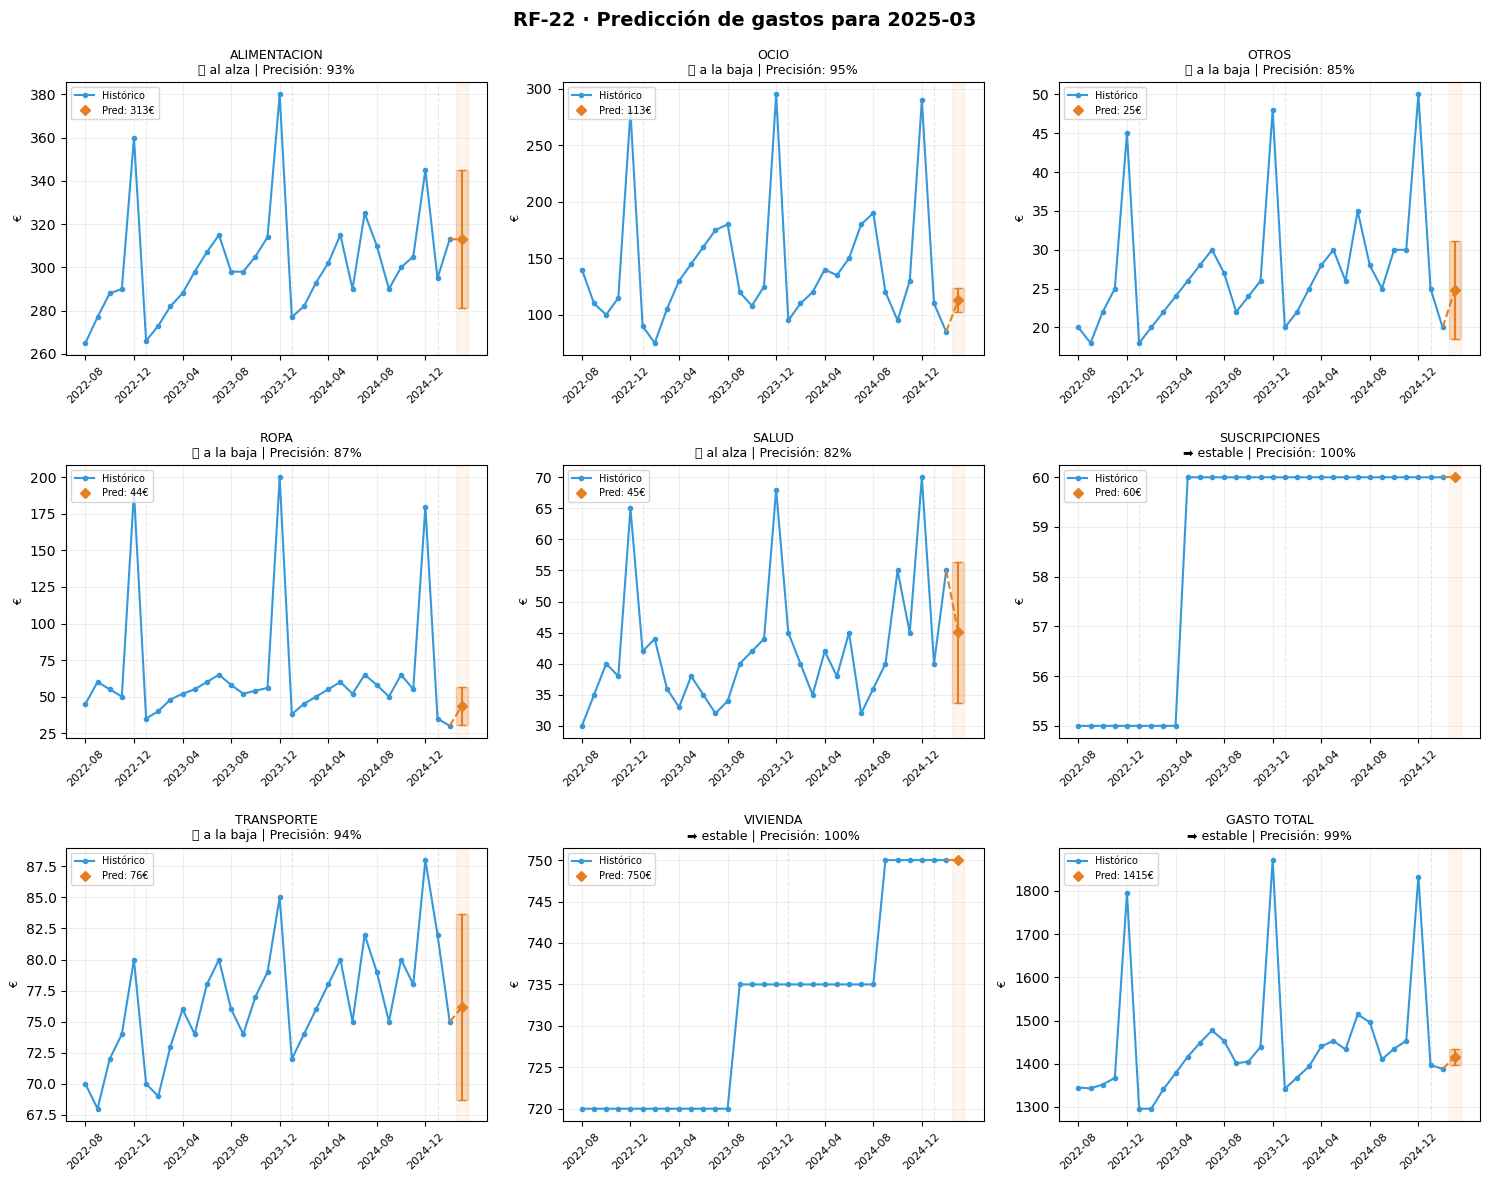

In [56]:
import matplotlib.pyplot as plt

# Determinar layout según número de categorías
n_cats  = len(categorias)
n_cols  = 3
n_rows  = (n_cats + n_cols) // n_cols  # +n_cols para incluir el total

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle(f"RF-22 · Predicción de gastos para {fecha_prediccion}", fontsize=14, fontweight="bold")
axes_flat = axes.flatten() if n_rows > 1 else list(axes)

etiquetas_x = meses_list + [fecha_prediccion]
n_puntos = len(etiquetas_x)

for idx, cat in enumerate(categorias + ["__total__"]):
    ax    = axes_flat[idx]
    res   = resultados[cat]
    hist  = res["historico"]
    pred  = res["prediccion"]
    pmin  = res["pred_min"]
    pmax  = res["pred_max"]
    titulo = "GASTO TOTAL" if cat == "__total__" else cat.upper()

    # --- LÓGICA ADAPTATIVA ---
    # Ajustar grosor y tamaño de puntos según volumen de datos
    lw = 1.5 if n_puntos > 12 else 2.0
    ms = 3 if n_puntos > 12 else 5
    
    # Decidir frecuencia de etiquetas en el eje X
    if n_puntos > 24:
        paso_labels = 4  # Etiqueta cada 4 meses
    elif n_puntos > 12:
        paso_labels = 2  # Etiqueta cada 2 meses
    else:
        paso_labels = 1  # Todas las etiquetas

    # Histórico
    x_hist = list(range(len(hist)))
    ax.plot(x_hist, hist, "o-", color="#3498db", linewidth=lw, markersize=ms, label="Histórico")

    # Predicción
    x_pred = len(hist)
    ax.plot([x_pred - 1, x_pred], [hist[-1], pred], "--", color="#e67e22", linewidth=1.5)
    ax.plot(x_pred, pred, "D", color="#e67e22", markersize=ms + 2, zorder=5, label=f"Pred: {pred:.0f}€")

    # Intervalo de confianza
    ax.fill_between([x_pred - 0.5, x_pred + 0.5], pmin, pmax, alpha=0.25, color="#e67e22")
    ax.errorbar(x_pred, pred, yerr=[[pred - pmin], [pmax - pred]], 
                fmt="none", color="#e67e22", capsize=3, linewidth=1.5)

    # --- CONFIGURACIÓN DE EJES ---
    ax.set_xticks(range(0, n_puntos, paso_labels))
    ax.set_xticklabels([etiquetas_x[i] for i in range(0, n_puntos, paso_labels)], 
                       rotation=45, fontsize=8)
    
    # Añadir líneas verticales para los Eneros (cambio de año) si hay muchos datos
    for i, etiqueta in enumerate(etiquetas_x):
        if "-01" in etiqueta:
            ax.axvline(i, color="gray", linestyle="--", alpha=0.2, linewidth=0.8)

    ax.set_title(f"{titulo}\n{res['tendencia']} | Precisión: {res['precision']*100:.0f}%", fontsize=9)
    ax.set_ylabel("€", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.2)

    # Resaltar zona de predicción
    ax.axvspan(x_pred - 0.5, x_pred + 0.5, alpha=0.07, color="#e67e22")

# Ocultar ejes sobrantes
for i in range(len(categorias) + 1, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4) # Espacio extra para títulos
plt.savefig("rf22_prediccion_optimizado.png", dpi=120, bbox_inches="tight")
plt.show()

## 📈 6. Detección de Tendencias por Categoría

In [57]:
def detectar_tendencia_detallada(serie: list, nombre: str) -> dict:
    """
    Analiza la tendencia de una serie con regresión lineal simple.
    Devuelve pendiente, dirección, magnitud y descripción.
    """
    if len(serie) < 2:
        return {"nombre": nombre, "direccion": "indeterminado", "pendiente": 0}

    x      = np.arange(len(serie), dtype=float)
    coeffs = np.polyfit(x, serie, 1)
    pend   = coeffs[0]
    media  = np.mean(serie)
    pct    = (pend / media * 100) if media > 0 else 0

    if pct > 5:
        direccion, icono = "al alza", "📈"
    elif pct < -5:
        direccion, icono = "a la baja", "📉"
    else:
        direccion, icono = "estable", "➡️"

    return {
        "nombre":    nombre,
        "direccion": direccion,
        "icono":     icono,
        "pendiente": round(float(pend), 2),
        "pct_mes":   round(float(pct), 1),
    }


print("Tendencias detectadas en el historial:\n")
tendencias = {}
for cat in categorias:
    t = detectar_tendencia_detallada(series[cat], cat)
    tendencias[cat] = t
    signo = "+" if t["pct_mes"] >= 0 else ""
    print(f"  {t['icono']} {cat:<20} {t['direccion']:<12}  {signo}{t['pct_mes']}% por mes  (Δ {signo}{t['pendiente']:.2f}€/mes)")

# Alerta categorías con crecimiento fuerte
alertas_tendencia = [t for t in tendencias.values() if t["pct_mes"] > 10]
if alertas_tendencia:
    print("\n⚠️  Categorías con crecimiento acelerado (>10%/mes):")
    for t in alertas_tendencia:
        print(f"   • {t['nombre']}: +{t['pct_mes']}%/mes — considera revisar estos gastos")


Tendencias detectadas en el historial:

  ➡️ alimentacion         estable       +0.3% por mes  (Δ +0.86€/mes)
  ➡️ ocio                 estable       +0.4% por mes  (Δ +0.57€/mes)
  ➡️ otros                estable       +0.9% por mes  (Δ +0.25€/mes)
  ➡️ ropa                 estable       +0.1% por mes  (Δ +0.08€/mes)
  ➡️ salud                estable       +0.8% por mes  (Δ +0.35€/mes)
  ➡️ suscripciones        estable       +0.3% por mes  (Δ +0.20€/mes)
  ➡️ transporte           estable       +0.4% por mes  (Δ +0.30€/mes)
  ➡️ vivienda             estable       +0.2% por mes  (Δ +1.16€/mes)


## ✅ 7. Evaluación de Precisión del Modelo
Criterio de aceptación: *«Precisión del modelo > 70% (evaluación continua)»*


In [58]:
print(f"Evaluación de precisión (umbral mínimo: {PRECISION_MINIMA*100:.0f}%)\n")
print(f"{'Categoría':<22} {'Precisión':>10} {'MAE':>10} {'Estado'}")
print("─" * 55)

precisions = []
for cat in categorias + ["__total__"]:
    res   = resultados[cat]
    p     = res["precision"]
    mae   = res["mae"]
    icon  = "✅" if res["cumple_umbral"] else "⚠️  BAJO UMBRAL"
    nombre = "TOTAL" if cat == "__total__" else cat
    print(f"{nombre:<22} {p*100:>9.1f}%  {mae:>8.2f}€  {icon}")
    precisions.append(p)

precision_global = np.mean(precisions)
print("─" * 55)
print(f"{'Precisión global promedio':<22} {precision_global*100:>9.1f}%")
print()
if precision_global >= PRECISION_MINIMA:
    print(f"✅ El modelo supera el umbral de {PRECISION_MINIMA*100:.0f}% de precisión global.")
else:
    print(f"⚠️  El modelo no alcanza el umbral de {PRECISION_MINIMA*100:.0f}%. Se recomienda:")
    print("   • Acumular más meses de historial")
    print("   • Revisar si hay transacciones atípicas en el historial")
    print("   • Considerar reentrenamiento tras el próximo mes real")


Evaluación de precisión (umbral mínimo: 70%)

Categoría               Precisión        MAE Estado
───────────────────────────────────────────────────────
alimentacion                93.0%     21.25€  ✅
ocio                        95.0%      7.13€  ✅
otros                       84.7%      4.22€  ✅
ropa                        87.0%      8.58€  ✅
salud                       82.5%      7.52€  ✅
suscripciones              100.0%      0.00€  ✅
transporte                  93.5%      4.99€  ✅
vivienda                   100.0%      0.00€  ✅
TOTAL                       99.2%     12.33€  ✅
───────────────────────────────────────────────────────
Precisión global promedio      92.8%

✅ El modelo supera el umbral de 70% de precisión global.


## 💬 8. Explicación en Lenguaje Simple

In [59]:
def generar_explicacion(resultados, meses_list, fecha_prediccion, categorias):
    """Genera texto explicativo para mostrar al usuario en la app."""
    total_res = resultados["__total__"]
    lineas = [
        f"📅 Predicción para {fecha_prediccion} basada en {len(meses_list)} meses de historial:",
        "",
        f"  💰 Gasto total estimado: {total_res['prediccion']:.2f}€",
        f"     Rango posible: entre {total_res['pred_min']:.0f}€ y {total_res['pred_max']:.0f}€",
        f"     Tendencia general: {total_res['tendencia']}",
        "",
        "  Por categorías:",
    ]
    for cat in sorted(categorias, key=lambda c: resultados[c]["prediccion"], reverse=True):
        r = resultados[cat]
        lineas.append(
            f"    • {cat:<18} {r['prediccion']:>8.2f}€  "
            f"[{r['pred_min']:.0f}–{r['pred_max']:.0f}€]  {r['tendencia']}"
        )
    lineas += [
        "",
        "  ℹ️  Cómo se calculó:",
        f"     El sistema analizó tus últimos {len(meses_list)} meses de gastos,",
        "     aprendió los patrones de cada categoría y proyectó el siguiente mes.",
        "     El rango (mínimo–máximo) indica la variabilidad esperada.",
        f"     Precisión global del modelo: {np.mean([resultados[c]['precision'] for c in categorias])*100:.0f}%",
    ]
    return "\n".join(lineas)


explicacion = generar_explicacion(resultados, meses_list, fecha_prediccion, categorias)
print(explicacion)


📅 Predicción para 2025-03 basada en 31 meses de historial:

  💰 Gasto total estimado: 1415.49€
     Rango posible: entre 1397€ y 1434€
     Tendencia general: ➡️ estable

  Por categorías:
    • vivienda             750.00€  [750–750€]  ➡️ estable
    • alimentacion         312.96€  [281–345€]  📈 al alza
    • ocio                 112.91€  [102–124€]  📉 a la baja
    • transporte            76.16€  [69–84€]  📉 a la baja
    • suscripciones         60.00€  [60–60€]  ➡️ estable
    • salud                 45.03€  [34–56€]  📈 al alza
    • ropa                  43.55€  [31–56€]  📉 a la baja
    • otros                 24.80€  [18–31€]  📉 a la baja

  ℹ️  Cómo se calculó:
     El sistema analizó tus últimos 31 meses de gastos,
     aprendió los patrones de cada categoría y proyectó el siguiente mes.
     El rango (mínimo–máximo) indica la variabilidad esperada.
     Precisión global del modelo: 92%


## 📤 9. Salida Estructurada (JSON)
Payload que devolverá el endpoint FastAPI.

In [60]:
salida = {
    "fecha_prediccion":  fecha_prediccion,
    "meses_analizados":  len(meses_list),
    "precision_global":  round(float(np.mean([resultados[c]["precision"] for c in categorias])), 3),
    "cumple_umbral": bool(precision_global >= PRECISION_MINIMA),
    "total": {
        "prediccion":  resultados["__total__"]["prediccion"],
        "pred_min":    resultados["__total__"]["pred_min"],
        "pred_max":    resultados["__total__"]["pred_max"],
        "tendencia":   resultados["__total__"]["tendencia"],
    },
    "por_categoria": {
        cat: {
            "prediccion": resultados[cat]["prediccion"],
            "pred_min":   resultados[cat]["pred_min"],
            "pred_max":   resultados[cat]["pred_max"],
            "tendencia":  resultados[cat]["tendencia"],
            "precision":  resultados[cat]["precision"],
        }
        for cat in categorias
    },
    "comparacion_mes_anterior": {
        cat: {
            "anterior":   round(meses_data[meses_list[-1]].get(cat, 0.0), 2),
            "prediccion": resultados[cat]["prediccion"],
            "delta":      round(resultados[cat]["prediccion"] - meses_data[meses_list[-1]].get(cat, 0.0), 2),
        }
        for cat in categorias
    },
    "alertas_tendencia": [
        {"categoria": t["nombre"], "pct_mes": t["pct_mes"]}
        for t in tendencias.values() if t["pct_mes"] > 10
    ],
    "explicacion": explicacion,
}

print(json.dumps(salida, ensure_ascii=False, indent=2))


{
  "fecha_prediccion": "2025-03",
  "meses_analizados": 31,
  "precision_global": 0.92,
  "cumple_umbral": true,
  "total": {
    "prediccion": 1415.49,
    "pred_min": 1396.99,
    "pred_max": 1433.98,
    "tendencia": "➡️ estable"
  },
  "por_categoria": {
    "alimentacion": {
      "prediccion": 312.96,
      "pred_min": 281.08,
      "pred_max": 344.85,
      "tendencia": "📈 al alza",
      "precision": 0.93
    },
    "ocio": {
      "prediccion": 112.91,
      "pred_min": 102.22,
      "pred_max": 123.61,
      "tendencia": "📉 a la baja",
      "precision": 0.95
    },
    "otros": {
      "prediccion": 24.8,
      "pred_min": 18.46,
      "pred_max": 31.13,
      "tendencia": "📉 a la baja",
      "precision": 0.847
    },
    "ropa": {
      "prediccion": 43.55,
      "pred_min": 30.67,
      "pred_max": 56.42,
      "tendencia": "📉 a la baja",
      "precision": 0.87
    },
    "salud": {
      "prediccion": 45.03,
      "pred_min": 33.75,
      "pred_max": 56.31,
      "tend

---
# HU-09 · Predicción de Gastos del Próximo Mes

> **Historia de usuario:** Como usuario con historial suficiente, quiero ver una predicción de cuánto gastaré el próximo mes, para planificar mejor mi presupuesto.

Esta sección extiende **RF-22** añadiendo:
- 📐 Modelos ARIMA y Prophet sobre el total mensual
- 🔍 Explicabilidad SHAP sobre el modelo de RF-22
- 📊 Cross-validation temporal (TimeSeriesSplit)
- 🏅 Indicador de confianza del modelo (semáforo)
- 🔔 Generador de notificación mensual
- 🤝 Ensemble final: combina RF-22 + ARIMA + Prophet


## 📦 Dependencias adicionales (HU-09)

In [61]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit
import shap
import logging
# Silenciar logs verbosos de Prophet y statsmodels
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("statsmodels").setLevel(logging.ERROR)

print("✅ Dependencias HU-09 cargadas.")


✅ Dependencias HU-09 cargadas.


## 📐 HU-09.1 — Modelo ARIMA sobre Gasto Total
ARIMA es adecuado para series temporales univariadas cortas. Con pocos meses
usamos órdenes bajos (1,1,0) para evitar sobreajuste.


In [62]:
def predecir_arima(serie: list, orden=(1, 1, 0)) -> dict:
    if len(serie) < 3:
        return {"error": "Necesita al menos 3 observaciones"}
    try:
        modelo_arima = ARIMA(serie, order=orden)
        fit          = modelo_arima.fit()
        forecast     = fit.get_forecast(steps=1)
        
        # 1. Acceso directo por índice (funciona en Array y Series)
        pred         = float(forecast.predicted_mean[0])
        
        # 2. El intervalo de confianza suele ser una matriz 2D
        ic           = forecast.conf_int(alpha=0.20)
        
        # Usamos [0, 0] y [0, 1] que es compatible con NumPy
        pred_min     = max(0.0, float(ic[0][0]))
        pred_max     = float(ic[0][1])
        
        aic          = round(fit.aic, 2)
        
        return {
            "prediccion": round(pred, 2),
            "pred_min":   round(pred_min, 2),
            "pred_max":   round(pred_max, 2),
            "aic":        aic,
            "orden":      orden,
        }
    except Exception as e:
        return {"error": str(e)}


serie_total = series["__total__"]
resultado_arima = predecir_arima(serie_total)

if "error" not in resultado_arima:
    print(f"📐 ARIMA{resultado_arima['orden']} — Gasto total predicho para {fecha_prediccion}")
    print(f"   Predicción central: {resultado_arima['prediccion']:.2f}€")
    print(f"   Intervalo 80%:      [{resultado_arima['pred_min']:.2f}€ — {resultado_arima['pred_max']:.2f}€]")
    print(f"   AIC (menor=mejor):  {resultado_arima['aic']}")
else:
    print(f"⚠️  ARIMA no disponible: {resultado_arima['error']}")


📐 ARIMA(1, 1, 0) — Gasto total predicho para 2025-03
   Predicción central: 1392.03€
   Intervalo 80%:      [1158.82€ — 1625.24€]
   AIC (menor=mejor):  401.6


## 🔮 HU-09.2 — Modelo Prophet sobre Gasto Total
Prophet maneja bien estacionalidad y es robusto con datos escasos.
Necesita al menos 2 puntos; con más datos captura estacionalidad anual automáticamente.


In [66]:
def predecir_prophet(serie: list, meses_list: list, fecha_prediccion: str) -> dict:
    """
    Ajusta Prophet a la serie mensual de totales.
    Devuelve predicción con intervalo de confianza.
    """
    if len(serie) < 2:
        return {"error": "Necesita al menos 2 observaciones"}
    try:
        # Construir DataFrame que requiere Prophet (ds=fecha, y=valor)
        fechas = [pd.Timestamp(m + "-01") for m in meses_list]
        df_prophet = pd.DataFrame({"ds": fechas, "y": serie})

        modelo_prophet = Prophet(
            interval_width=0.80,
            yearly_seasonality=False,   # sin datos suficientes para anual
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode="additive",
        )
        modelo_prophet.fit(df_prophet)

        # Predecir el mes siguiente
        anio, mes = fecha_prediccion.split("-")
        fecha_pred_ts = pd.Timestamp(f"{fecha_prediccion}-01")
        future = pd.DataFrame({"ds": [fecha_pred_ts]})
        forecast = modelo_prophet.predict(future)

        pred     = max(0.0, float(forecast["yhat"].iloc[0]))
        pred_min = max(0.0, float(forecast["yhat_lower"].iloc[0]))
        pred_max = float(forecast["yhat_upper"].iloc[0])

        return {
            "prediccion": round(pred, 2),
            "pred_min":   round(pred_min, 2),
            "pred_max":   round(pred_max, 2),
        }
    except Exception as e:
        return {"error": str(e)}


resultado_prophet = predecir_prophet(serie_total, meses_list, fecha_prediccion)

if "error" not in resultado_prophet:
    print(f"🔮 Prophet — Gasto total predicho para {fecha_prediccion}")
    print(f"   Predicción central: {resultado_prophet['prediccion']:.2f}€")
    print(f"   Intervalo 80%:      [{resultado_prophet['pred_min']:.2f}€ — {resultado_prophet['pred_max']:.2f}€]")
else:
    print(f"⚠️  Prophet no disponible: {resultado_prophet['error']}")


🔮 Prophet — Gasto total predicho para 2025-03
   Predicción central: 1504.71€
   Intervalo 80%:      [1325.49€ — 1660.56€]


## 📊 HU-09.3 — Cross-Validation Temporal (TimeSeriesSplit)
Evalúa los modelos de RF-22 respetando el orden cronológico de los datos.
No mezclamos futuro con pasado en ningún fold.


In [67]:
def cross_val_temporal(serie: list) -> dict:
    """
    TimeSeriesSplit adaptativo: ajusta ventana y número de splits
    al volumen real de datos disponibles.

    Lógica de adaptación:
      - n_meses <= 4  → ventana=1, 1 split  (mínimo viable)
      - n_meses <= 7  → ventana=1, 2 splits
      - n_meses <= 11 → ventana=2, 3 splits
      - n_meses >= 12 → ventana=2, 5 splits
    """
    n = len(serie)

    if n <= 4:
        ventana, n_splits = 1, 1
    elif n <= 7:
        ventana, n_splits = 1, 2
    elif n <= 11:
        ventana, n_splits = 2, 3
    else:
        ventana, n_splits = 2, 5

    X, y = construir_features(serie, ventana)

    # Seguridad extra: nunca más splits que muestras - 1
    n_splits = min(n_splits, len(X) - 1)

    if len(X) < 2 or n_splits < 1:
        # Caso límite absoluto: estimación basada en varianza de la serie
        sigma  = float(np.std(serie)) if len(serie) > 1 else 0.0
        media  = float(np.mean(serie))
        mape_est = (sigma / media * 100) if media > 0 else 0.0
        return {
            "mae_promedio":  round(sigma, 2),
            "mape_promedio": round(mape_est, 1),
            "n_folds":       0,
            "accuracy_pct":  round(max(0, 100 - mape_est), 1),
            "nota":          "Estimación estadística (historial mínimo)",
        }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    modelo_cv, _ = seleccionar_modelo(len(X))
    maes, mapes  = [], []

    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        if len(X_tr) == 0:
            continue
        modelo_cv.fit(X_tr, y_tr)
        pred      = modelo_cv.predict(X_te)
        maes.append(mean_absolute_error(y_te, pred))
        mape_vals = np.abs((y_te - pred) / (y_te + 1e-6)) * 100
        mapes.append(float(np.mean(mape_vals)))

    if not maes:
        return {"mae_promedio": None, "mape_promedio": None, "n_folds": 0, "accuracy_pct": None}

    return {
        "mae_promedio":  round(float(np.mean(maes)), 2),
        "mape_promedio": round(float(np.mean(mapes)), 1),
        "n_folds":       len(maes),
        "accuracy_pct":  round(float(100 - np.mean(mapes)), 1),
        "ventana_usada": ventana,
    }


print("Cross-validation temporal por categoría\n")
print(f"{'Categoría':<22} {'MAE (€)':>10} {'MAPE (%)':>10} {'Accuracy':>10} {'Folds':>7} {'Nota'}")
print("─" * 80)

cv_resultados = {}
for cat in categorias + ["__total__"]:
    cv = cross_val_temporal(series[cat])
    cv_resultados[cat] = cv
    nombre = "TOTAL" if cat == "__total__" else cat
    mae_str  = f"{cv['mae_promedio']:.2f}€"  if cv["mae_promedio"]  is not None else "—"
    mape_str = f"{cv['mape_promedio']:.1f}%" if cv["mape_promedio"] is not None else "—"
    acc_str  = f"{cv['accuracy_pct']:.1f}%"  if cv["accuracy_pct"]  is not None else "—"
    nota     = cv.get("nota", f"ventana={cv.get('ventana_usada', '?')}")
    print(f"{nombre:<22} {mae_str:>10} {mape_str:>10} {acc_str:>10} {cv['n_folds']:>7}  {nota}")

Cross-validation temporal por categoría

Categoría                 MAE (€)   MAPE (%)   Accuracy   Folds Nota
────────────────────────────────────────────────────────────────────────────────
alimentacion               10.37€       3.2%      96.8%       5  ventana=2
ocio                       19.14€      14.3%      85.7%       5  ventana=2
otros                       2.89€      10.0%      90.0%       5  ventana=2
ropa                        6.78€      11.7%      88.3%       5  ventana=2
salud                       5.53€      13.1%      86.9%       5  ventana=2
suscripciones               0.00€       0.0%     100.0%       5  ventana=2
transporte                  3.00€       3.8%      96.2%       5  ventana=2
vivienda                    3.00€       0.4%      99.6%       5  ventana=2
TOTAL                      27.84€       1.9%      98.1%       5  ventana=2


## 🔍 HU-09.4 — Explicabilidad SHAP sobre el Modelo de RF-22
Explica qué features influyen más en la predicción del gasto total y de cada categoría.


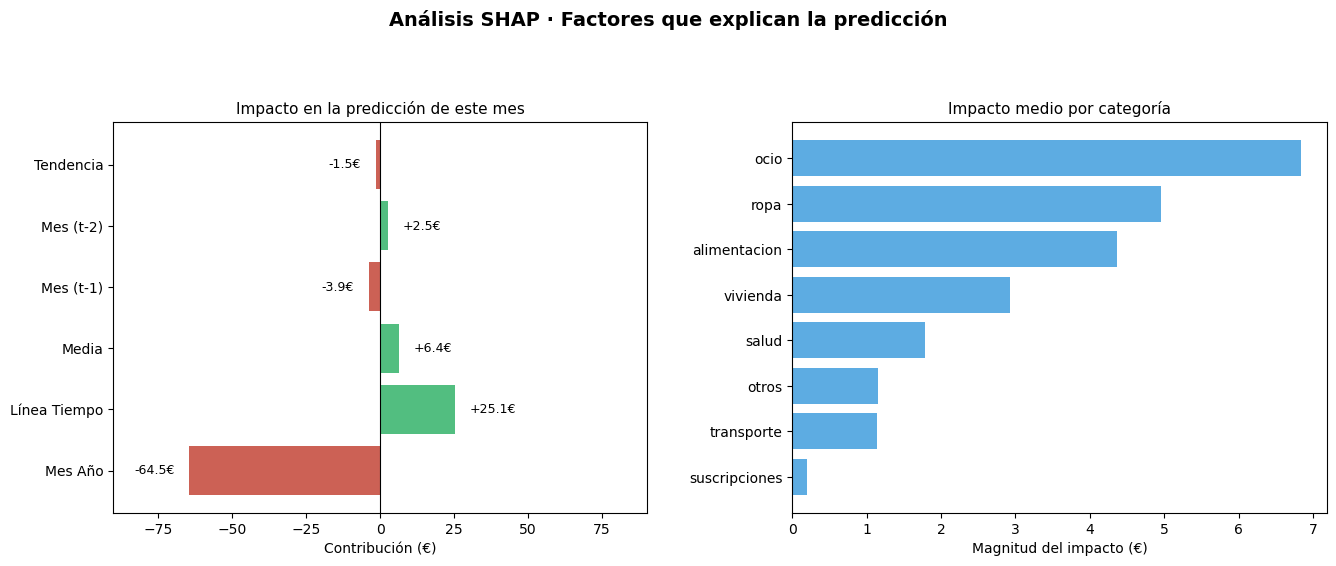


💡 Resumen de inteligencia:
El factor 'Mes Año' es el más influyente este mes,
empujando la predicción a disminuir en 64.49€.


In [69]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def calcular_shap_categoria(serie: list, ventana: int = 2):
    """Entrena el modelo, calcula SHAP y devuelve valores para la predicción del siguiente mes."""
    X, y = construir_features(serie, ventana)
    if len(X) == 0:
        return None, None, None
    
    modelo_sh, _ = seleccionar_modelo(len(X))
    lags_next  = serie[-ventana:]
    media_next = float(np.mean(lags_next))
    tend_next  = lags_next[-1] - lags_next[0] if ventana > 1 else 0.0
    idx_next   = len(serie)
    ultimo_mes = int(meses_list[-1].split("-")[1])
    mes_next   = (ultimo_mes % 12) + 1
    X_next     = np.array([list(lags_next) + [media_next, tend_next, idx_next, mes_next]])
    
    # --- CORRECCIÓN DE DETECCIÓN DE MODELO ---
    # Entrenamos primero
    modelo_sh.fit(X, y)
    
    try:
        # Usamos el Explainer genérico que detecta automáticamente el tipo de modelo
        # Para modelos de Scikit-Learn (Tree o Linear), suele funcionar directo
        explainer = shap.Explainer(modelo_sh, X)
        shap_vals = explainer(X_next)
        
        # Extraer los valores (depende de la versión de SHAP, .values es lo estándar ahora)
        if hasattr(shap_vals, "values"):
            resultado = shap_vals.values[0]
        else:
            resultado = shap_vals[0]
            
    except Exception as e:
        # Fallback para modelos muy específicos o versiones antiguas
        if "Linear" in str(type(modelo_sh)):
            explainer = shap.LinearExplainer(modelo_sh, X)
        else:
            explainer = shap.TreeExplainer(modelo_sh)
        
        shap_vals = explainer.shap_values(X_next)
        resultado = shap_vals[0] if len(shap_vals.shape) > 1 else shap_vals

    return resultado, explainer, X

# Calcular SHAP para el total
# Asegúrate de que 'serie_total' esté definida (series["__total__"])
serie_total = series["__total__"]
shap_total, explainer_total, X_total = calcular_shap_categoria(serie_total)

if shap_total is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Análisis SHAP · Factores que explican la predicción", fontsize=14, fontweight="bold")

    # 1. Gráfico de contribución individual (Waterfall simplificado)
    # Definir nombres de features si no existen
    feat_names_base = [f"Mes (t-{i})" for i in range(2, 0, -1)] + ["Media", "Tendencia", "Línea Tiempo", "Mes Año"]
    
    vals   = shap_total
    n_feat = min(len(vals), len(feat_names_base))
    pairs  = sorted(zip(feat_names_base[:n_feat], vals[:n_feat]), key=lambda x: abs(x[1]), reverse=True)
    names_s, vals_s = zip(*pairs)
    
    colors_shap = ["#27ae60" if v > 0 else "#c0392b" for v in vals_s]
    bars = axes[0].barh(names_s, vals_s, color=colors_shap, alpha=0.8)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_title("Impacto en la predicción de este mes", fontsize=11)
    axes[0].set_xlabel("Contribución (€)")

    # Añadir etiquetas de texto a las barras
    limit = max(abs(v) for v in vals_s) * 1.4
    axes[0].set_xlim(-limit, limit)
    for bar, val in zip(bars, vals_s):
        axes[0].text(val + (5 if val > 0 else -5), bar.get_y() + bar.get_height()/2, 
                     f"{val:+.1f}€", va="center", ha="left" if val > 0 else "right", fontsize=9)

    # 2. Importancia por Categorías
    importancias_cat = {}
    for cat in categorias:
        sv, _, _ = calcular_shap_categoria(series[cat])
        if sv is not None:
            importancias_cat[cat] = float(np.mean(np.abs(sv)))
    
    if importancias_cat:
        cats_sorted = sorted(importancias_cat, key=importancias_cat.get)
        imp_vals    = [importancias_cat[c] for c in cats_sorted]
        axes[1].barh(cats_sorted, imp_vals, color="#3498db", alpha=0.8)
        axes[1].set_title("Impacto medio por categoría", fontsize=11)
        axes[1].set_xlabel("Magnitud del impacto (€)")
    
    plt.tight_layout(pad=3.0)
    plt.show()

    # Mensaje resumen
    factor_top = pairs[0]
    sentido = "aumentar" if factor_top[1] > 0 else "disminuir"
    print(f"\n💡 Resumen de inteligencia:")
    print(f"El factor '{factor_top[0]}' es el más influyente este mes,")
    print(f"empujando la predicción a {sentido} en {abs(factor_top[1]):.2f}€.")

## 🤝 HU-09.5 — Ensemble: RF-22 + ARIMA + Prophet
Combinamos los tres modelos ponderando por su precisión individual.
El modelo con mejor accuracy tiene más peso en la predicción final.


In [70]:
def ensemble_ponderado(pred_rf22, pred_arima, pred_prophet,
                       acc_rf22, acc_arima=None, acc_prophet=None) -> dict:
    """
    Media ponderada por precisión. Si un modelo no está disponible, se excluye.
    """
    modelos = []
    if pred_rf22 is not None and acc_rf22 > 0:
        modelos.append(("RF-22 (GBM/RF)", pred_rf22, max(acc_rf22, 0.01)))
    if pred_arima is not None and "error" not in resultado_arima:
        acc_a = acc_arima if acc_arima else 0.70  # estimación conservadora para ARIMA
        modelos.append(("ARIMA", pred_arima, acc_a))
    if pred_prophet is not None and "error" not in resultado_prophet:
        acc_p = acc_prophet if acc_prophet else 0.70
        modelos.append(("Prophet", pred_prophet, acc_p))

    if not modelos:
        return {"error": "No hay modelos disponibles"}

    total_peso = sum(w for _, _, w in modelos)
    pred_final = sum(p * w / total_peso for _, p, w in modelos)

    return {
        "prediccion_ensemble": round(pred_final, 2),
        "contribuciones": [
            {"modelo": n, "prediccion": round(p, 2), "peso": round(w / total_peso, 3)}
            for n, p, w in modelos
        ],
        "n_modelos": len(modelos),
    }


# Recoger precisiones
acc_rf22_total = resultados["__total__"]["precision"]
cv_total       = cv_resultados.get("__total__", {})
acc_cv         = cv_total.get("accuracy_pct", 70) / 100 if "error" not in cv_total else 0.70

pred_arima_val   = resultado_arima.get("prediccion") if "error" not in resultado_arima else None
pred_prophet_val = resultado_prophet.get("prediccion") if "error" not in resultado_prophet else None

ensemble = ensemble_ponderado(
    pred_rf22    = resultados["__total__"]["prediccion"],
    pred_arima   = pred_arima_val,
    pred_prophet = pred_prophet_val,
    acc_rf22     = acc_rf22_total,
    acc_arima    = acc_cv,
    acc_prophet  = acc_cv,
)

print(f"🤝 Predicción Ensemble para {fecha_prediccion}\n")
if "error" not in ensemble:
    print(f"   {'Modelo':<20} {'Predicción':>12} {'Peso':>8}")
    print("   " + "─" * 42)
    for c in ensemble["contribuciones"]:
        print(f"   {c['modelo']:<20} {c['prediccion']:>10.2f}€  {c['peso']*100:>6.1f}%")
    print("   " + "─" * 42)
    print(f"   {'ENSEMBLE FINAL':<20} {ensemble['prediccion_ensemble']:>10.2f}€  {'100.0%':>7}")

    # Intervalo de confianza combinado
    preds_disponibles = [c["prediccion"] for c in ensemble["contribuciones"]]
    ic_min = max(0.0, min(preds_disponibles) * 0.88)
    ic_max = max(preds_disponibles) * 1.12
    print(f"\n   Rango de confianza combinado: [{ic_min:.0f}€ — {ic_max:.0f}€]")
else:
    print(f"   ⚠️ {ensemble['error']}")
    ensemble["prediccion_ensemble"] = resultados["__total__"]["prediccion"]
    ic_min = resultados["__total__"]["pred_min"]
    ic_max = resultados["__total__"]["pred_max"]


🤝 Predicción Ensemble para 2025-03

   Modelo                 Predicción     Peso
   ──────────────────────────────────────────
   RF-22 (GBM/RF)          1415.49€    33.6%
   ARIMA                   1392.03€    33.2%
   Prophet                 1504.71€    33.2%
   ──────────────────────────────────────────
   ENSEMBLE FINAL          1437.33€   100.0%

   Rango de confianza combinado: [1225€ — 1685€]


## 🏅 HU-09.6 — Indicador de Confianza del Modelo
Semáforo visual que el usuario ve en la app junto a la predicción.
Se basa en: precisión del modelo, meses de historial, acuerdo entre modelos y tendencia estable.


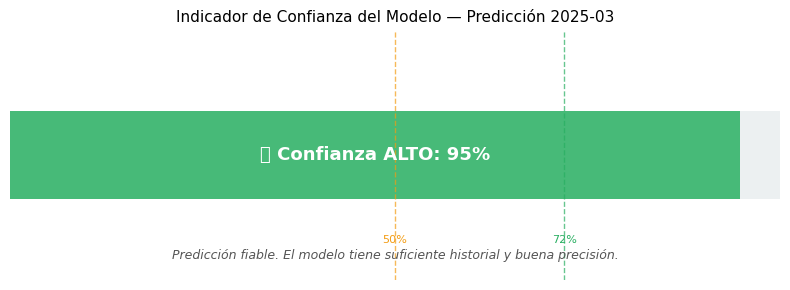


🟢 Nivel de confianza: ALTO (95%)
   Predicción fiable. El modelo tiene suficiente historial y buena precisión.


In [71]:
def calcular_indicador_confianza(precision_global, n_meses, n_modelos_ensemble,
                                  preds_modelos, mape_cv=None) -> dict:
    """
    Devuelve nivel de confianza: ALTO / MEDIO / BAJO con justificación.
    Criterios:
      - Precisión global (peso 40%)
      - Meses de historial (peso 25%)
      - Acuerdo entre modelos ensemble (peso 20%)
      - MAPE cross-validation (peso 15%)
    """
    score = 0.0

    # Precisión
    score += precision_global * 0.40

    # Historial
    hist_score = min(n_meses / 12, 1.0)  # satura en 12 meses
    score += hist_score * 0.25

    # Acuerdo entre modelos (menor dispersión = mayor confianza)
    if len(preds_modelos) > 1:
        dispersion = np.std(preds_modelos) / (np.mean(preds_modelos) + 1e-6)
        acuerdo    = max(0, 1 - dispersion * 3)
        score += acuerdo * 0.20
    else:
        score += 0.10  # penalización por un solo modelo

    # MAPE CV
    if mape_cv is not None:
        mape_score = max(0, 1 - mape_cv / 100)
        score += mape_score * 0.15
    else:
        score += 0.075  # sin datos de CV

    score = float(np.clip(score, 0, 1))

    if score >= 0.72:
        nivel, color, emoji = "ALTO",  "#27ae60", "🟢"
        desc = "Predicción fiable. El modelo tiene suficiente historial y buena precisión."
    elif score >= 0.50:
        nivel, color, emoji = "MEDIO", "#f39c12", "🟡"
        desc = "Predicción orientativa. Acumula más meses para mejorar la precisión."
    else:
        nivel, color, emoji = "BAJO",  "#e74c3c", "🔴"
        desc = "Predicción poco fiable. Se necesita más historial o revisar transacciones atípicas."

    return {"score": round(score, 3), "nivel": nivel, "color": color,
            "emoji": emoji, "descripcion": desc}


mape_cv_total = cv_total.get("mape_promedio") if "error" not in cv_total else None
preds_ensemble = [c["prediccion"] for c in ensemble.get("contribuciones", [])] or [resultados["__total__"]["prediccion"]]

confianza = calcular_indicador_confianza(
    precision_global   = precision_global,
    n_meses            = n_meses,
    n_modelos_ensemble = ensemble.get("n_modelos", 1),
    preds_modelos      = preds_ensemble,
    mape_cv            = mape_cv_total,
)

# Visualización del semáforo
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Barra de confianza
ax.barh(0.5, confianza["score"], height=0.35, color=confianza["color"],
        alpha=0.85, left=0)
ax.barh(0.5, 1 - confianza["score"], height=0.35, color="#ecf0f1",
        left=confianza["score"])
ax.axvline(0.50, color="#f39c12", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(0.72, color="#27ae60", linestyle="--", linewidth=1, alpha=0.7)
ax.text(0.50, 0.15, "50%", ha="center", fontsize=8, color="#f39c12")
ax.text(0.72, 0.15, "72%", ha="center", fontsize=8, color="#27ae60")
ax.text(confianza["score"] / 2, 0.5,
        f"{confianza['emoji']} Confianza {confianza['nivel']}: {confianza['score']*100:.0f}%",
        ha="center", va="center", fontsize=13, fontweight="bold", color="white")
ax.text(0.5, 0.1, confianza["descripcion"], ha="center", va="center",
        fontsize=9, style="italic", color="#555")
ax.set_title(f"Indicador de Confianza del Modelo — Predicción {fecha_prediccion}", fontsize=11)

plt.tight_layout()
plt.savefig("hu09_confianza.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n{confianza['emoji']} Nivel de confianza: {confianza['nivel']} ({confianza['score']*100:.0f}%)")
print(f"   {confianza['descripcion']}")


## 🔔 HU-09.7 — Notificación Mensual con Predicción
Genera el payload de la notificación push/email que se enviará al usuario al inicio de cada mes.


In [72]:
def generar_notificacion(fecha_prediccion, ensemble, confianza,
                          resultados, categorias, meses_list) -> dict:
    """
    Genera el payload de notificación para la app.
    Incluye título corto, cuerpo y datos estructurados para el deep link.
    """
    pred_total   = ensemble.get("prediccion_ensemble", resultados["__total__"]["prediccion"])
    mes_anterior = meses_list[-1]
    total_ant    = sum(meses_data[mes_anterior].values())
    delta        = pred_total - total_ant
    delta_str    = f"{delta:+.0f}€" if abs(delta) > 5 else "similar al mes pasado"

    # Categoría con mayor predicción (excluye vivienda si es fija)
    cat_mayor = max(
        [c for c in categorias if c != "vivienda"],
        key=lambda c: resultados[c]["prediccion"],
        default=categorias[0]
    )

    # Construir texto según tendencia
    tend_total = resultados["__total__"]["tendencia"]
    if "alza" in tend_total:
        resumen = f"tus gastos suben respecto al mes anterior ({delta_str})"
    elif "baja" in tend_total:
        resumen = f"tus gastos bajan respecto al mes anterior ({delta_str})"
    else:
        resumen = f"tus gastos se mantienen estables ({delta_str})"

    return {
        "tipo":    "prediccion_mensual",
        "titulo":  f"📊 Predicción para {fecha_prediccion}: {pred_total:.0f}€",
        "cuerpo":  (
            f"Este mes {resumen}. "
            f"El mayor gasto estimado es en {cat_mayor} ({resultados[cat_mayor]['prediccion']:.0f}€). "
            f"Confianza del modelo: {confianza['nivel'].lower()}."
        ),
        "datos": {
            "fecha_prediccion":  fecha_prediccion,
            "gasto_total_pred":  pred_total,
            "gasto_total_ant":   round(total_ant, 2),
            "delta":             round(delta, 2),
            "confianza_nivel":   confianza["nivel"],
            "confianza_score":   confianza["score"],
            "categoria_mayor":   cat_mayor,
            "deep_link":         f"finora://prediccion/{fecha_prediccion}",
        },
        "programar_envio": f"{fecha_prediccion}-01T08:00:00",
    }


notificacion = generar_notificacion(
    fecha_prediccion, ensemble, confianza, resultados, categorias, meses_list
)

print("🔔 Payload de notificación mensual generado:\n")
print(json.dumps(notificacion, ensure_ascii=False, indent=2))


🔔 Payload de notificación mensual generado:

{
  "tipo": "prediccion_mensual",
  "titulo": "📊 Predicción para 2025-03: 1437€",
  "cuerpo": "Este mes tus gastos se mantienen estables (+49€). El mayor gasto estimado es en alimentacion (313€). Confianza del modelo: alto.",
  "datos": {
    "fecha_prediccion": "2025-03",
    "gasto_total_pred": 1437.33,
    "gasto_total_ant": 1388.0,
    "delta": 49.33,
    "confianza_nivel": "ALTO",
    "confianza_score": 0.948,
    "categoria_mayor": "alimentacion",
    "deep_link": "finora://prediccion/2025-03"
  },
  "programar_envio": "2025-03-01T08:00:00"
}


## 📤 Salida Final Combinada (RF-22 + HU-09)
Payload JSON completo del endpoint `/prediccion-gastos`.

In [73]:
salida_completa = {
    **salida,   # payload base de RF-22
    "hu09": {
        "ensemble": {
            "prediccion_total":  ensemble.get("prediccion_ensemble"),
            "ic_min":            round(ic_min, 2),
            "ic_max":            round(ic_max, 2),
            "modelos":           ensemble.get("contribuciones", []),
        },
        "modelos_adicionales": {
            "arima":   resultado_arima,
            "prophet": resultado_prophet,
        },
        "cross_validation": {
            cat: cv_resultados[cat]
            for cat in (categorias + ["__total__"])
            if "error" not in cv_resultados.get(cat, {"error": True})
        },
        "confianza": {
            "nivel":      confianza["nivel"],
            "score":      confianza["score"],
            "descripcion": confianza["descripcion"],
        },
        "notificacion": notificacion,
        "shap_disponible": shap_total is not None,
    }
}

print(json.dumps(salida_completa, ensure_ascii=False, indent=2))


{
  "fecha_prediccion": "2025-03",
  "meses_analizados": 31,
  "precision_global": 0.92,
  "cumple_umbral": true,
  "total": {
    "prediccion": 1415.49,
    "pred_min": 1396.99,
    "pred_max": 1433.98,
    "tendencia": "➡️ estable"
  },
  "por_categoria": {
    "alimentacion": {
      "prediccion": 312.96,
      "pred_min": 281.08,
      "pred_max": 344.85,
      "tendencia": "📈 al alza",
      "precision": 0.93
    },
    "ocio": {
      "prediccion": 112.91,
      "pred_min": 102.22,
      "pred_max": 123.61,
      "tendencia": "📉 a la baja",
      "precision": 0.95
    },
    "otros": {
      "prediccion": 24.8,
      "pred_min": 18.46,
      "pred_max": 31.13,
      "tendencia": "📉 a la baja",
      "precision": 0.847
    },
    "ropa": {
      "prediccion": 43.55,
      "pred_min": 30.67,
      "pred_max": 56.42,
      "tendencia": "📉 a la baja",
      "precision": 0.87
    },
    "salud": {
      "prediccion": 45.03,
      "pred_min": 33.75,
      "pred_max": 56.31,
      "tend